## 1. Setup

In [1]:
import os, io, json, random
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_auc_score,
                             average_precision_score, roc_curve)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

DATA = "/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset"
OUT = "/kaggle/working"
IMG, BATCH = 224, 32
CLASSES = ["Benign", "Malignant"]      # Benign = 0, Malignant = 1
print(tf.__version__, keras.__version__, tf.config.list_physical_devices("GPU"))

2.20.0 3.13.2 [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Load file lists and basic EDA

TRAIN
 label
Benign       6289
Malignant    5590
Name: count, dtype: int64 

TEST
 label
Benign       1000
Malignant    1000
Name: count, dtype: int64


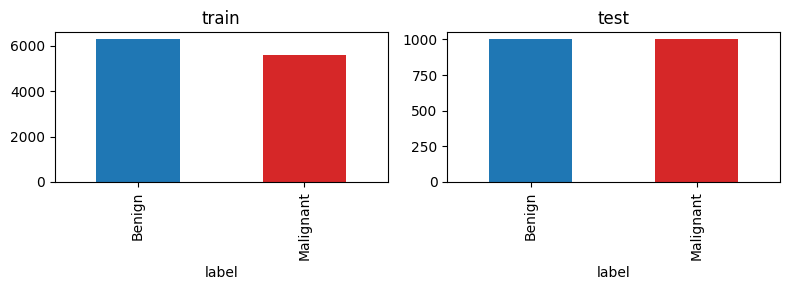

In [2]:
def make_df(split):
    rows = []
    for label in CLASSES:
        folder = os.path.join(DATA, split, label)
        for f in sorted(os.listdir(folder)):
            rows.append({"image_path": os.path.join(folder, f), "label": label})
    return pd.DataFrame(rows)

train_all = make_df("train")
test_df = make_df("test")
print("TRAIN\n", train_all.label.value_counts(), "\n\nTEST\n", test_df.label.value_counts())

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
for a, (name, d) in zip(ax, [("train", train_all), ("test", test_df)]):
    d.label.value_counts().reindex(CLASSES).plot.bar(ax=a, title=name, color=["tab:blue", "tab:red"])
plt.tight_layout(); plt.show()

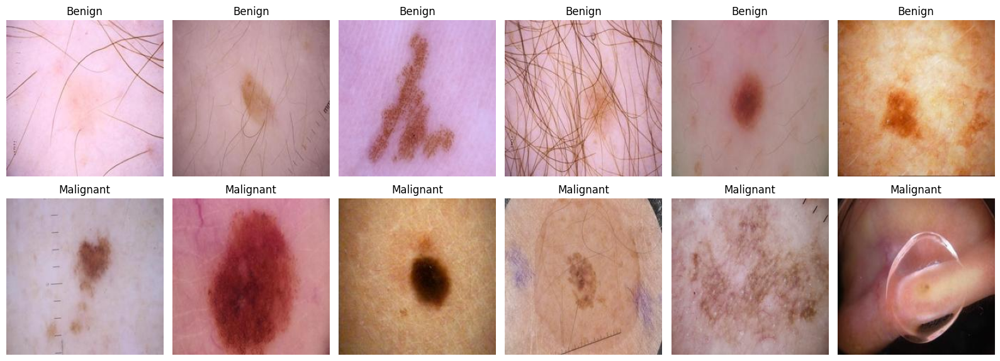

In [3]:
fig, axes = plt.subplots(2, 6, figsize=(16, 6))
for r, label in enumerate(CLASSES):
    paths = train_all[train_all.label == label].sample(6, random_state=SEED).image_path
    for c, p in enumerate(paths):
        axes[r, c].imshow(Image.open(p).convert("RGB")); axes[r, c].set_title(label); axes[r, c].axis("off")
plt.tight_layout(); plt.show()

## 3. Leakage checks
This dataset has **no patient IDs**, so we cannot split by patient. Best available steps:
- A perceptual hash (dHash) finds near-identical images (resized / re-encoded copies) that an MD5 check misses.
- Test images that look like a training image are **removed from the test set**.
- Near-duplicate images inside train are put in the **same group**, so they cannot land in both train and validation.

This is a heuristic. It reduces leakage; it does not prove there is none.

In [4]:
def dhash(path, size=8):
    img = Image.open(path).convert("L").resize((size + 1, size), Image.LANCZOS)
    a = np.asarray(img, dtype=np.int16)
    return np.packbits((a[:, 1:] > a[:, :-1]).flatten())     # 8 bytes = 64 bits

POP = np.array([bin(i).count("1") for i in range(256)], dtype=np.uint8)
def hamming(a, B):
    return POP[np.bitwise_xor(B, a)].sum(axis=1)

train_h = np.stack([dhash(p) for p in train_all.image_path])
test_h = np.stack([dhash(p) for p in test_df.image_path])
THR_DUP = 3      # max Hamming distance (out of 64 bits) to call two images near-duplicates

test_min_dist = np.array([hamming(h, train_h).min() for h in test_h])
test_df["near_dup_of_train"] = test_min_dist <= THR_DUP
print("Test images that are near-duplicates of a train image:",
      int(test_df.near_dup_of_train.sum()), "of", len(test_df))
test_clean = test_df[~test_df.near_dup_of_train].reset_index(drop=True)
print("Clean test set:", len(test_clean)); print(test_clean.label.value_counts())

Test images that are near-duplicates of a train image: 1069 of 2000
Clean test set: 931
label
Benign       596
Malignant    335
Name: count, dtype: int64


In [5]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.model_selection import StratifiedGroupKFold

n = len(train_h); rows_i, cols_j = [], []
for i in range(n - 1):
    d = hamming(train_h[i], train_h[i + 1:])
    j = np.where(d <= THR_DUP)[0] + i + 1
    rows_i += [i] * len(j); cols_j += j.tolist()
adj = coo_matrix((np.ones(len(rows_i)), (rows_i, cols_j)), shape=(n, n))
_, group_id = connected_components(adj, directed=False)
train_all["group"] = group_id
sizes = train_all.group.value_counts()
print("Groups:", len(sizes), "| images in multi-image groups:", int(sizes[sizes > 1].sum()),
      "| largest group:", int(sizes.iloc[0]))
if sizes.iloc[0] > 0.01 * n:
    print("WARNING: one group is >1% of the data - lower THR_DUP.")

y_all = (train_all.label == "Malignant").astype(int)
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
tr_idx, va_idx = next(sgkf.split(train_all, y_all, groups=train_all.group))
train_df = train_all.iloc[tr_idx].reset_index(drop=True)
val_df = train_all.iloc[va_idx].reset_index(drop=True)
assert set(train_df.group).isdisjoint(set(val_df.group))
print("Train:", len(train_df), dict(train_df.label.value_counts()))
print("Val  :", len(val_df), dict(val_df.label.value_counts()))

Groups: 9134 | images in multi-image groups: 3294 | largest group: 1922
Train: 10926 {'Benign': np.int64(5868), 'Malignant': np.int64(5058)}
Val  : 953 {'Malignant': np.int64(532), 'Benign': np.int64(421)}


## 4. Preprocessing and augmentation
- Preprocessing = `resnet50.preprocess_input` (what the ImageNet weights were trained with). Same function for train, val, test, and the app.
- Augmentation on **train only**: small rotation/shift/zoom, horizontal + vertical flips (lesions have no "up"), mild brightness change, `reflect` fill (avoids streaky borders).
- Classes are roughly balanced (about 53/47), so no class weights.

Found 10926 validated image filenames belonging to 2 classes.
Found 953 validated image filenames belonging to 2 classes.
Found 931 validated image filenames belonging to 2 classes.
{'Benign': 0, 'Malignant': 1}
Found 10926 validated image filenames belonging to 2 classes.


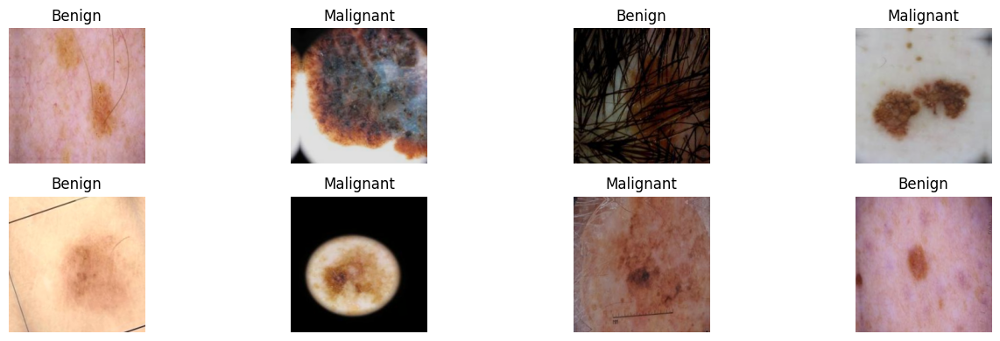

In [6]:
AUG = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1, zoom_range=0.1,
           horizontal_flip=True, vertical_flip=True, brightness_range=(0.85, 1.15), fill_mode="reflect")

train_gen = ImageDataGenerator(preprocessing_function=preprocess_input, **AUG).flow_from_dataframe(
    train_df, x_col="image_path", y_col="label", classes=CLASSES, target_size=(IMG, IMG),
    batch_size=BATCH, class_mode="binary", shuffle=True, seed=SEED)
plain = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = plain.flow_from_dataframe(val_df, x_col="image_path", y_col="label", classes=CLASSES,
    target_size=(IMG, IMG), batch_size=BATCH, class_mode="binary", shuffle=False)
test_gen = plain.flow_from_dataframe(test_clean, x_col="image_path", y_col="label", classes=CLASSES,
    target_size=(IMG, IMG), batch_size=BATCH, class_mode="binary", shuffle=False)
print(train_gen.class_indices)

# visual check of augmentation (no preprocess_input so colors look normal)
viz = ImageDataGenerator(**AUG).flow_from_dataframe(train_df, x_col="image_path", y_col="label",
    classes=CLASSES, target_size=(IMG, IMG), batch_size=8, class_mode="binary", seed=SEED)
xb, yb = next(viz)
plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1); plt.imshow(xb[i] / 255.0); plt.title(CLASSES[int(yb[i])]); plt.axis("off")
plt.tight_layout(); plt.show()

## 5. Model: ResNet50 (frozen) + new head
`base(inputs, training=False)` keeps BatchNorm in inference mode, even later during fine-tuning. That avoids the unstable validation curves in the first notebook.

In [7]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMG, IMG, 3), name="resnet50_base")
base_model.trainable = False

inputs = keras.Input((IMG, IMG, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.Dropout(0.5, name="drop")(x)
outputs = layers.Dense(1, activation="sigmoid", name="out")(x)
model = keras.Model(inputs, outputs)

def metric_list():
    return ["accuracy", keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"), keras.metrics.AUC(name="auc")]

def make_callbacks(name):
    return [keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
            keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-7),
            keras.callbacks.ModelCheckpoint(f"{OUT}/{name}.keras", monitor="val_loss", save_best_only=True)]

model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=metric_list())
print("Trainable params:", sum(int(np.prod(w.shape)) for w in model.trainable_weights))

I0000 00:00:1790276578.721161      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790276578.724139      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params: 2049


## 6. Phase 1 - train the head only (backbone frozen)

In [8]:
h1 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=make_callbacks("resnet50_frozen"))

Epoch 1/15
  1/342 ━━━━━━━━━━━━━━━━━━━━ 1:22:57 15s/step - accuracy: 0.4688 - auc: 0.4980 - loss: 1.2641 - precision: 0.4000 - recall: 0.1250

I0000 00:00:1790276597.533898     134 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


342/342 ━━━━━━━━━━━━━━━━━━━━ 184s 497ms/step - accuracy: 0.8177 - auc: 0.8978 - loss: 0.4122 - precision: 0.8145 - recall: 0.7849 - val_accuracy: 0.8562 - val_auc: 0.9397 - val_loss: 0.3213 - val_precision: 0.8584 - val_recall: 0.8891 - learning_rate: 0.0010
Epoch 2/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 160s 466ms/step - accuracy: 0.8662 - auc: 0.9401 - loss: 0.3118 - precision: 0.8672 - recall: 0.8395 - val_accuracy: 0.8804 - val_auc: 0.9507 - val_loss: 0.2821 - val_precision: 0.9066 - val_recall: 0.8759 - learning_rate: 0.0010
Epoch 4/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 158s 463ms/step - accuracy: 0.8710 - auc: 0.9408 - loss: 0.3092 - precision: 0.8703 - recall: 0.8478 - val_accuracy: 0.8709 - val_auc: 0.9496 - val_loss: 0.2955 - val_precision: 0.9252 - val_recall: 0.8365 - learning_rate: 0.0010
Epoch 5/15
342/342 ━━━━━━━━━━━━━━━━━━━━ 163s 475ms/step - accuracy: 0.8726 - auc: 0.9440 - loss: 0.3010 - precision: 0.8739 - recall: 0.8470 - val_accuracy: 0.8604 - val_auc: 0.9491 - val_loss: 0.3119 

## 7. Phase 2 - fine-tune the last 30 layers (BatchNorm stays frozen)
Small learning rate (1e-5) so pretrained features are adjusted gently instead of destroyed.

In [9]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
print("Trainable backbone layers:", sum(l.trainable for l in base_model.layers))

model.compile(optimizer=keras.optimizers.Adam(1e-5), loss="binary_crossentropy", metrics=metric_list())
h2 = model.fit(train_gen, validation_data=val_gen, epochs=20, callbacks=make_callbacks("resnet50_finetuned"))

Trainable backbone layers: 21
Epoch 1/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 189s 504ms/step - accuracy: 0.8792 - auc: 0.9509 - loss: 0.2816 - precision: 0.8779 - recall: 0.8584 - val_accuracy: 0.8783 - val_auc: 0.9548 - val_loss: 0.2759 - val_precision: 0.9127 - val_recall: 0.8647 - learning_rate: 1.0000e-05
Epoch 2/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 169s 494ms/step - accuracy: 0.9031 - auc: 0.9661 - loss: 0.2338 - precision: 0.9013 - recall: 0.8879 - val_accuracy: 0.8993 - val_auc: 0.9633 - val_loss: 0.2487 - val_precision: 0.9241 - val_recall: 0.8929 - learning_rate: 1.0000e-05
Epoch 4/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 160s 467ms/step - accuracy: 0.9167 - auc: 0.9761 - loss: 0.1962 - precision: 0.9145 - recall: 0.9047 - val_accuracy: 0.9066 - val_auc: 0.9671 - val_loss: 0.2300 - val_precision: 0.9203 - val_recall: 0.9117 - learning_rate: 1.0000e-05
Epoch 7/20
342/342 ━━━━━━━━━━━━━━━━━━━━ 161s 471ms/step - accuracy: 0.9251 - auc: 0.9795 - loss: 0.1818 - precision: 0.9232 - recall: 0.9144 - val_a

## 8. Training curves (dashed line = start of fine-tuning)

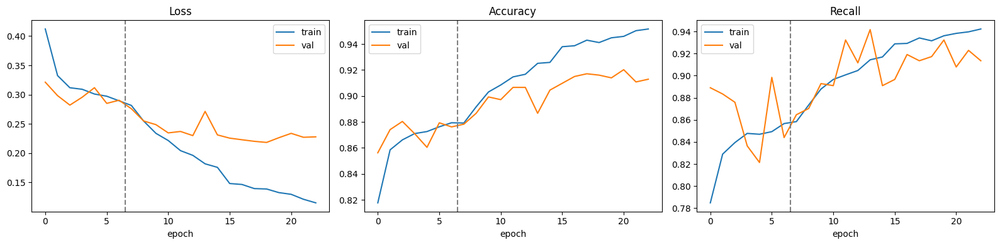

In [10]:
def cat(k): return h1.history[k] + h2.history[k]
split_at = len(h1.history["loss"])
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for a, (k, title) in zip(ax, [("loss", "Loss"), ("accuracy", "Accuracy"), ("recall", "Recall")]):
    a.plot(cat(k), label="train"); a.plot(cat("val_" + k), label="val")
    a.axvline(split_at - 0.5, ls="--", c="gray"); a.set_title(title); a.set_xlabel("epoch"); a.legend()
plt.tight_layout(); plt.show()

## 9. Baseline: small CNN from scratch
A simple reference point, so we can tell whether ResNet50 transfer learning actually helps.

In [11]:
baseline = keras.Sequential([
    layers.Input((IMG, IMG, 3)), layers.Rescaling(1 / 128.0),
    layers.Conv2D(32, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation="relu"), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation="relu"), layers.MaxPooling2D(),
    layers.GlobalAveragePooling2D(), layers.Dropout(0.3), layers.Dense(1, activation="sigmoid")])
baseline.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy", metrics=metric_list())
hb = baseline.fit(train_gen, validation_data=val_gen, epochs=12, callbacks=make_callbacks("baseline_cnn"))

Epoch 1/12


2026-09-24 20:06:45.084615: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 20:06:45.236371: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


113/342 ━━━━━━━━━━━━━━━━━━━━ 1:43 454ms/step - accuracy: 0.6678 - auc: 0.7199 - loss: 0.6036 - precision: 0.7261 - recall: 0.4488

2026-09-24 20:07:41.566725: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 20:07:41.712702: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


342/342 ━━━━━━━━━━━━━━━━━━━━ 178s 497ms/step - accuracy: 0.7486 - auc: 0.8268 - loss: 0.5136 - precision: 0.7803 - recall: 0.6360 - val_accuracy: 0.7555 - val_auc: 0.8607 - val_loss: 0.4960 - val_precision: 0.8534 - val_recall: 0.6786 - learning_rate: 0.0010
Epoch 2/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 161s 470ms/step - accuracy: 0.7728 - auc: 0.8493 - loss: 0.4789 - precision: 0.7742 - recall: 0.7191 - val_accuracy: 0.7775 - val_auc: 0.8641 - val_loss: 0.4720 - val_precision: 0.7920 - val_recall: 0.8158 - learning_rate: 0.0010
Epoch 3/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 160s 468ms/step - accuracy: 0.7701 - auc: 0.8544 - loss: 0.4709 - precision: 0.7619 - recall: 0.7321 - val_accuracy: 0.7775 - val_auc: 0.8734 - val_loss: 0.4663 - val_precision: 0.8101 - val_recall: 0.7857 - learning_rate: 0.0010
Epoch 4/12
342/342 ━━━━━━━━━━━━━━━━━━━━ 162s 473ms/step - accuracy: 0.7764 - auc: 0.8631 - loss: 0.4587 - precision: 0.7612 - recall: 0.7533 - val_accuracy: 0.7681 - val_auc: 0.8557 - val_loss: 0.4798 

## 10. Choose the decision threshold on VALIDATION data only
We pick the threshold with the highest specificity that still reaches the target sensitivity.
Change `TARGET_SENS` to reflect how costly missed malignant cases are. The test set is **not** used here.

In [12]:
def metrics_at(y, p, thr):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn); spec = tn / (tn + fp)
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1 = 2 * prec * sens / (prec + sens) if (prec + sens) else 0.0
    return dict(threshold=round(float(thr), 3), accuracy=(tp + tn) / len(y), precision=prec,
                sensitivity=sens, specificity=spec, f1=f1, tp=tp, fp=fp, fn=fn, tn=tn)

val_true = val_gen.classes
val_prob = model.predict(val_gen).ravel()
sweep = pd.DataFrame([metrics_at(val_true, val_prob, t) for t in np.arange(0.05, 0.96, 0.05)])
print(sweep.round(3).to_string(index=False))

TARGET_SENS = 0.90
ok = sweep[sweep.sensitivity >= TARGET_SENS]
if len(ok):
    THRESH = float(ok.sort_values("specificity", ascending=False).iloc[0].threshold)
else:
    THRESH = float(sweep.assign(j=sweep.sensitivity + sweep.specificity - 1).sort_values("j").iloc[-1].threshold)
print("\nChosen threshold:", THRESH)

30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 236ms/step
 threshold  accuracy  precision  sensitivity  specificity    f1  tp  fp  fn  tn
      0.05     0.845      0.787        0.989        0.663 0.877 526 142   6 279
      0.10     0.867      0.817        0.981        0.722 0.892 522 117  10 304
      0.15     0.875      0.834        0.970        0.755 0.897 516 103  16 318
      0.20     0.887      0.856        0.959        0.796 0.904 510  86  22 335
      0.25     0.890      0.866        0.949        0.815 0.906 505  78  27 343
      0.30     0.896      0.880        0.942        0.838 0.910 501  68  31 353
      0.35     0.903      0.893        0.940        0.857 0.916 500  60  32 361
      0.40     0.913      0.915        0.930        0.891 0.923 495  46  37 375
      0.45     0.915      0.925        0.923        0.905 0.924 491  40  41 381
      0.50     0.916      0.931        0.917        0.914 0.924 488  36  44 385
      0.55     0.913      0.931        0.912        0.914 0.921 485  36  47 38

## 11. Final evaluation on the held-out test set

In [13]:
def full_metrics(name, y, p, thr):
    m = metrics_at(y, p, thr)
    m["roc_auc"] = roc_auc_score(y, p); m["pr_auc"] = average_precision_score(y, p); m["model"] = name
    return m

test_true = test_gen.classes
frozen = keras.models.load_model(f"{OUT}/resnet50_frozen.keras")
best_base = keras.models.load_model(f"{OUT}/baseline_cnn.keras")

p_base = best_base.predict(test_gen).ravel()
p_frozen = frozen.predict(test_gen).ravel()
p_ft = model.predict(test_gen).ravel()

table = pd.DataFrame([
    full_metrics("Baseline CNN @0.5", test_true, p_base, 0.5),
    full_metrics("ResNet50 frozen @0.5", test_true, p_frozen, 0.5),
    full_metrics("ResNet50 fine-tuned @0.5", test_true, p_ft, 0.5),
    full_metrics(f"ResNet50 fine-tuned @{THRESH:.2f}", test_true, p_ft, THRESH)])
cols = ["model", "accuracy", "precision", "sensitivity", "specificity", "f1", "roc_auc", "pr_auc", "fn", "fp"]
print(table[cols].round(3).to_string(index=False))

30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 12s 269ms/step
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 169ms/step
                    model  accuracy  precision  sensitivity  specificity    f1  roc_auc  pr_auc  fn  fp
        Baseline CNN @0.5     0.834      0.732        0.848        0.826 0.786    0.914   0.859  51 104
     ResNet50 frozen @0.5     0.886      0.838        0.848        0.908 0.843    0.950   0.931  51  55
 ResNet50 fine-tuned @0.5     0.910      0.860        0.896        0.918 0.877    0.968   0.957  35  49
ResNet50 fine-tuned @0.60     0.924      0.902        0.884        0.946 0.893    0.968   0.957  39  32


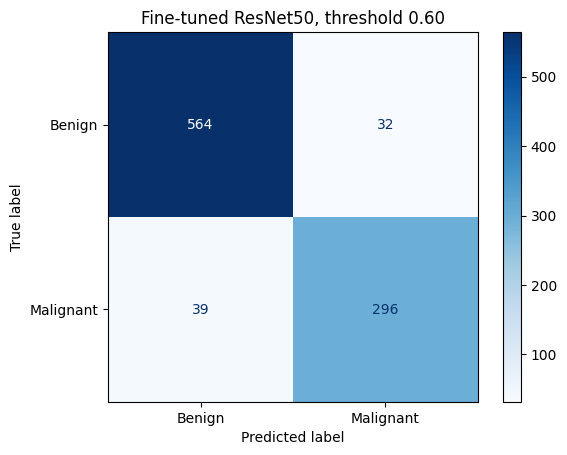

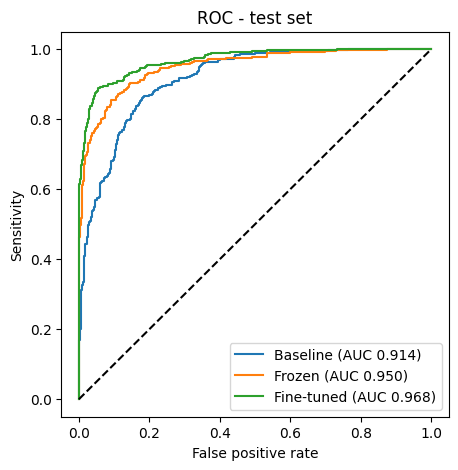

In [14]:
pred_ft = (p_ft >= THRESH).astype(int)
ConfusionMatrixDisplay(confusion_matrix(test_true, pred_ft), display_labels=CLASSES).plot(cmap="Blues")
plt.title(f"Fine-tuned ResNet50, threshold {THRESH:.2f}"); plt.show()

plt.figure(figsize=(5, 5))
for name, p in [("Baseline", p_base), ("Frozen", p_frozen), ("Fine-tuned", p_ft)]:
    fpr, tpr, _ = roc_curve(test_true, p); plt.plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(test_true, p):.3f})")
plt.plot([0, 1], [0, 1], "k--"); plt.xlabel("False positive rate"); plt.ylabel("Sensitivity")
plt.title("ROC - test set"); plt.legend(); plt.show()

## 12. Error analysis
Shows all four groups. False negatives (missed malignant) are listed with the **lowest probability first** = the most confident mistakes.
Do not over-explain single images; look for patterns (dark/blurry images, hair, unusual lighting) and treat them as hypotheses.

FN=39  FP=32  TP=296  TN=564


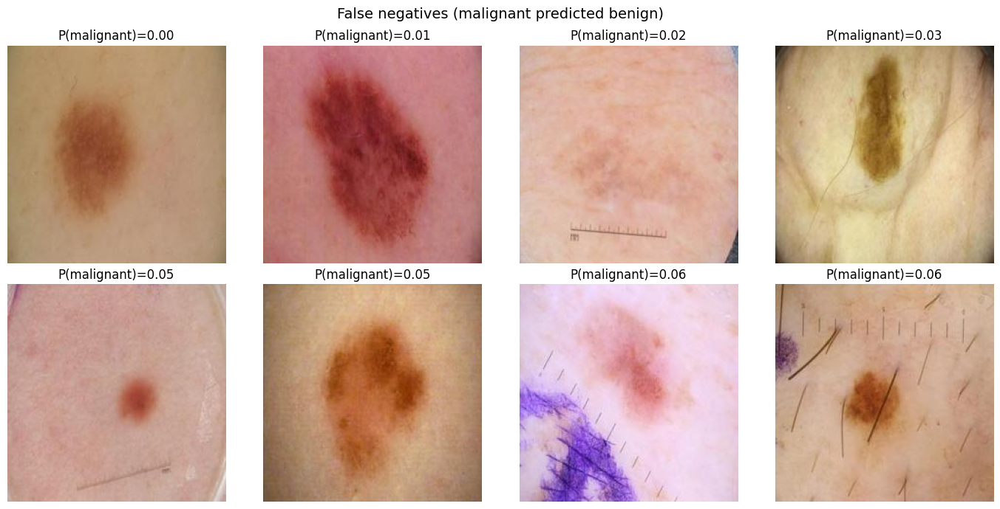

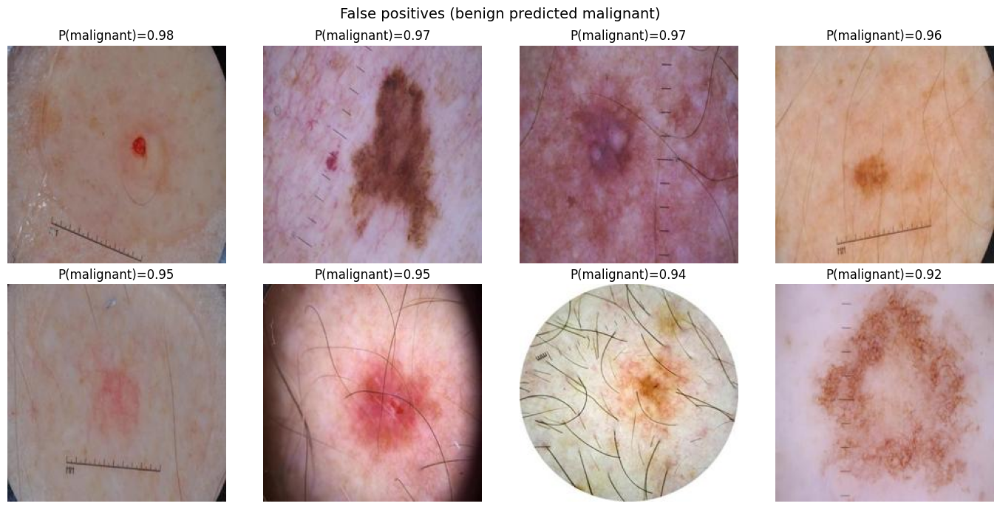

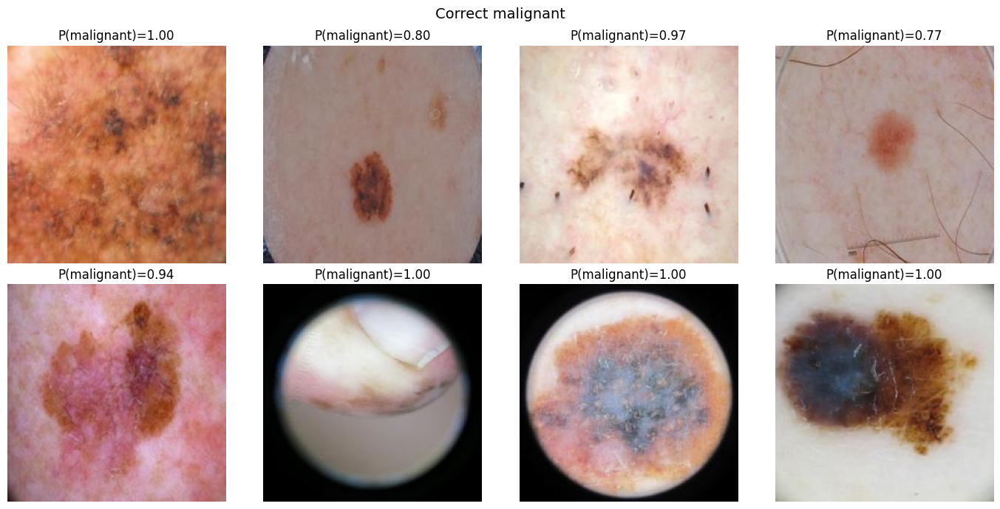

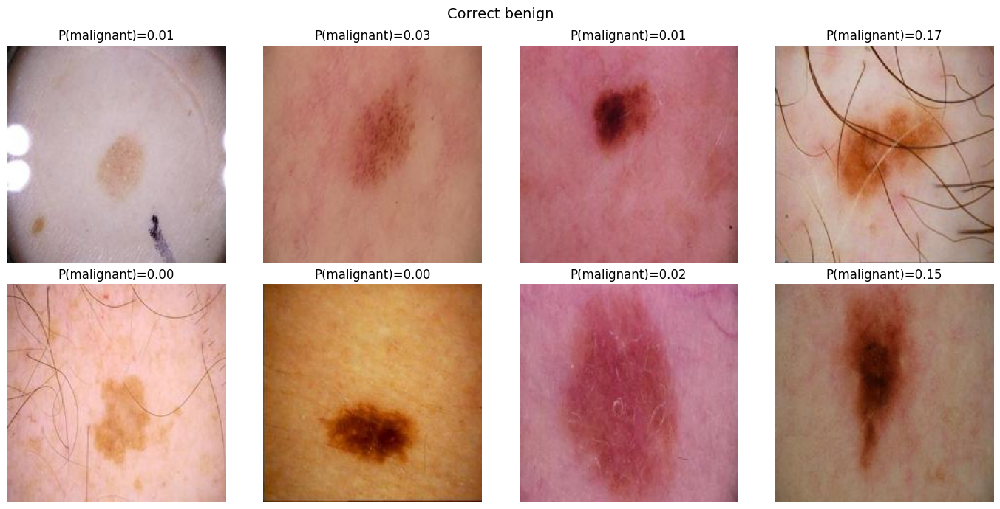

In [ ]:
res = test_clean.copy()
res["prob"], res["true"], res["pred"] = p_ft, test_true, pred_ft
FN = res[(res.true == 1) & (res.pred == 0)].sort_values("prob")
FP = res[(res.true == 0) & (res.pred == 1)].sort_values("prob", ascending=False)
TP = res[(res.true == 1) & (res.pred == 1)]
TN = res[(res.true == 0) & (res.pred == 0)]
print(f"FN={len(FN)}  FP={len(FP)}  TP={len(TP)}  TN={len(TN)}")

def show_grid(d, title, n=8):
    d = d.head(n) if title.startswith("False") else d.sample(min(n, len(d)), random_state=SEED)
    fig, axes = plt.subplots(2, 4, figsize=(14, 7)); fig.suptitle(title, fontsize=14)
    for a in axes.ravel(): a.axis("off")
    for a, (_, r) in zip(axes.ravel(), d.iterrows()):
        a.imshow(Image.open(r.image_path).convert("RGB")); a.set_title(f"P(malignant)={r.prob:.2f}")
    plt.tight_layout(); plt.show()

show_grid(FN, "False negatives (malignant predicted benign)")
show_grid(FP, "False positives (benign predicted malignant)")
show_grid(TP, "Correct malignant")
show_grid(TN, "Correct benign")

## 13. Grad-CAM
Heatmap of where the last conv block pushes the prediction toward "malignant". It is an **interpretability aid only**: it does not prove the model reasons like a clinician. Check whether it looks at the lesion or at borders, rulers and other artifacts.

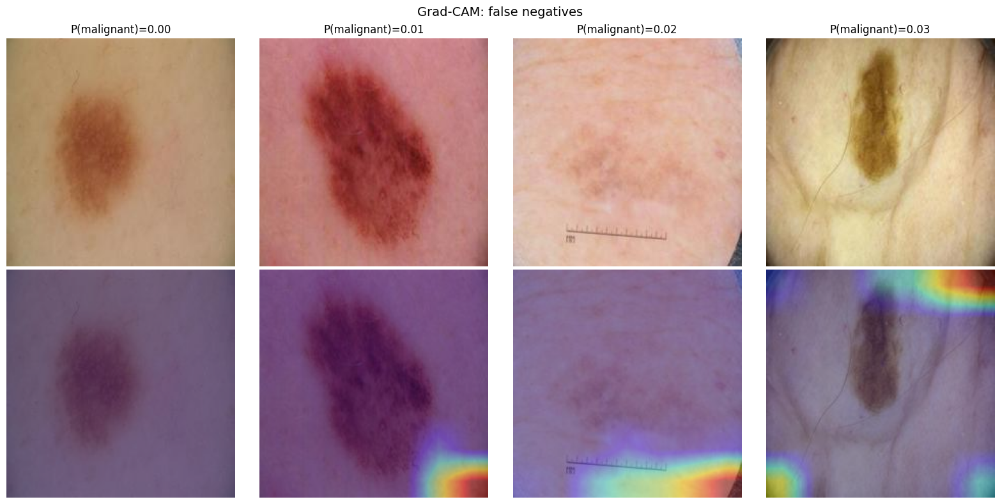

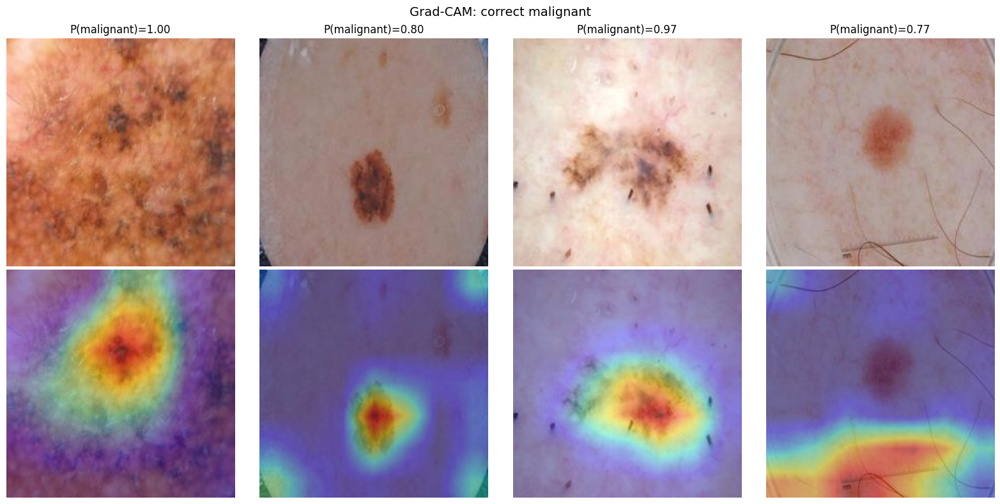

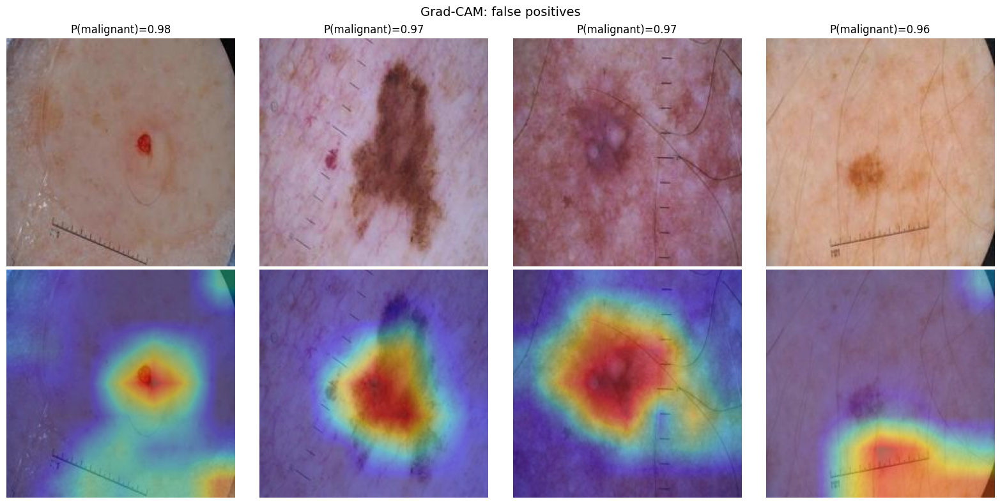

In [ ]:
def gradcam(m, path):
    base = m.get_layer("resnet50_base")
    gap, drop, out = m.get_layer("gap"), m.get_layer("drop"), m.get_layer("out")
    arr = np.array(keras.utils.load_img(path, target_size=(IMG, IMG)))
    x = tf.convert_to_tensor(preprocess_input(arr.astype("float32")[None].copy()))
    with tf.GradientTape() as tape:
        conv = base(x, training=False)
        tape.watch(conv)
        p = out(drop(gap(conv), training=False))
    grads = tape.gradient(p, conv)
    w = tf.reduce_mean(grads, axis=(1, 2), keepdims=True)
    cam = tf.nn.relu(tf.reduce_sum(w * conv, axis=-1))[0].numpy()
    cam = cam / (cam.max() + 1e-8)
    cam = np.array(Image.fromarray((cam * 255).astype("uint8")).resize((IMG, IMG), Image.BILINEAR)) / 255.0
    return arr, cam, float(p.numpy()[0, 0])

def show_cams(d, title, n=4):
    d = d.head(n)
    fig, axes = plt.subplots(2, len(d), figsize=(4 * len(d), 8)); fig.suptitle(title, fontsize=14)
    for k, (_, r) in enumerate(d.iterrows()):
        arr, cam, p = gradcam(model, r.image_path)
        axes[0, k].imshow(arr); axes[0, k].set_title(f"P(malignant)={p:.2f}"); axes[0, k].axis("off")
        axes[1, k].imshow(arr); axes[1, k].imshow(cam, cmap="jet", alpha=0.4); axes[1, k].axis("off")
    plt.tight_layout(); plt.show()

show_cams(FN, "Grad-CAM: false negatives")
show_cams(TP.sample(4, random_state=SEED), "Grad-CAM: correct malignant")
show_cams(FP, "Grad-CAM: false positives")

## 14. Robustness (fine-tuned model, chosen threshold)

In [ ]:
def perturb(img, kind):
    if kind == "brightness x0.7": return ImageEnhance.Brightness(img).enhance(0.7)
    if kind == "brightness x1.3": return ImageEnhance.Brightness(img).enhance(1.3)
    if kind == "rotate 15deg": return img.rotate(15, resample=Image.BILINEAR)
    if kind == "JPEG q=30":
        buf = io.BytesIO(); img.save(buf, "JPEG", quality=30); buf.seek(0); return Image.open(buf).convert("RGB")
    if kind == "down/up 112px": return img.resize((112, 112)).resize((IMG, IMG))
    return img

def predict_perturbed(kind):
    paths, probs = list(test_clean.image_path), []
    for i in range(0, len(paths), 64):
        batch = [np.array(perturb(Image.open(p).convert("RGB").resize((IMG, IMG)), kind)) for p in paths[i:i + 64]]
        probs.append(model.predict(preprocess_input(np.array(batch, dtype="float32")), verbose=0).ravel())
    return np.concatenate(probs)

rows = []
for kind in ["none", "brightness x0.7", "brightness x1.3", "rotate 15deg", "JPEG q=30", "down/up 112px"]:
    m = full_metrics(kind, test_true, predict_perturbed(kind), THRESH)
    rows.append({k: m[k] for k in ["model", "roc_auc", "sensitivity", "specificity"]})
print(pd.DataFrame(rows).round(3).to_string(index=False))

          model  roc_auc  sensitivity  specificity
           none    0.968        0.884        0.946
brightness x0.7    0.964        0.863        0.921
brightness x1.3    0.969        0.839        0.948
   rotate 15deg    0.922        0.994        0.250
      JPEG q=30    0.959        0.866        0.911
  down/up 112px    0.966        0.893        0.904


## 15. Save the final model + inference settings
Download: **Save Version -> Save & Run All (Commit)** -> open the version's **Output** tab -> download the files.
The Streamlit app must use `preprocess_input` and the saved threshold.

In [ ]:
FINAL = f"{OUT}/skin_lesion_resnet50.keras"
model.save(FINAL)
with open(f"{OUT}/inference_config.json", "w") as f:
    json.dump({"threshold": THRESH, "img_size": IMG, "classes": CLASSES,
               "preprocessing": "tensorflow.keras.applications.resnet50.preprocess_input"}, f, indent=2)
print(os.path.exists(FINAL), round(os.path.getsize(FINAL) / 1e6, 1), "MB")
print(os.listdir(OUT))

True 210.5 MB
['.virtual_documents', 'resnet50_frozen.keras', 'resnet50_finetuned.keras', 'skin_lesion_resnet50.keras', 'inference_config.json', 'baseline_cnn.keras']
